# test dataset

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


In [2]:
from a_datasets.gsm.data import HierarchicalGSM
import numpy as np

model = HierarchicalGSM(sigma_z=0.5, lambdas=(1.0, 0.25),
                        A=None, sigma_x=0.1, seed=0)

z, y, x = model.sample_joint(n=10_000)
print(f"x stats:  mean = {x.mean(0)},  std = {x.std(0)}")
print(f"kurtosis (x_1, x_2) = "
        f"({((x[:,0]**4).mean() / x[:,0].var()**2):.2f}, "
        f"{((x[:,1]**4).mean() / x[:,1].var()**2):.2f})  "
        f"(Gaussian == 3)")

# Sanity check: closed-form posterior mean recovers y reasonably well
mean, cov = model.posterior_y_given_x_moments(x[:200])
err = np.linalg.norm(mean - y[:200], axis=1).mean()
naive = np.linalg.norm(x[:200] - y[:200], axis=1).mean()
print(f"Mean ||E[y|x] - y||: {err:.3f}    vs naive ||x - y||: {naive:.3f}")



x stats:  mean = [ 0.00186782 -0.00171084],  std = [1.05769121 0.54398773]
kurtosis (x_1, x_2) = (3.77, 3.85)  (Gaussian == 3)
Mean ||E[y|x] - y||: 0.130    vs naive ||x - y||: 0.133


# plot

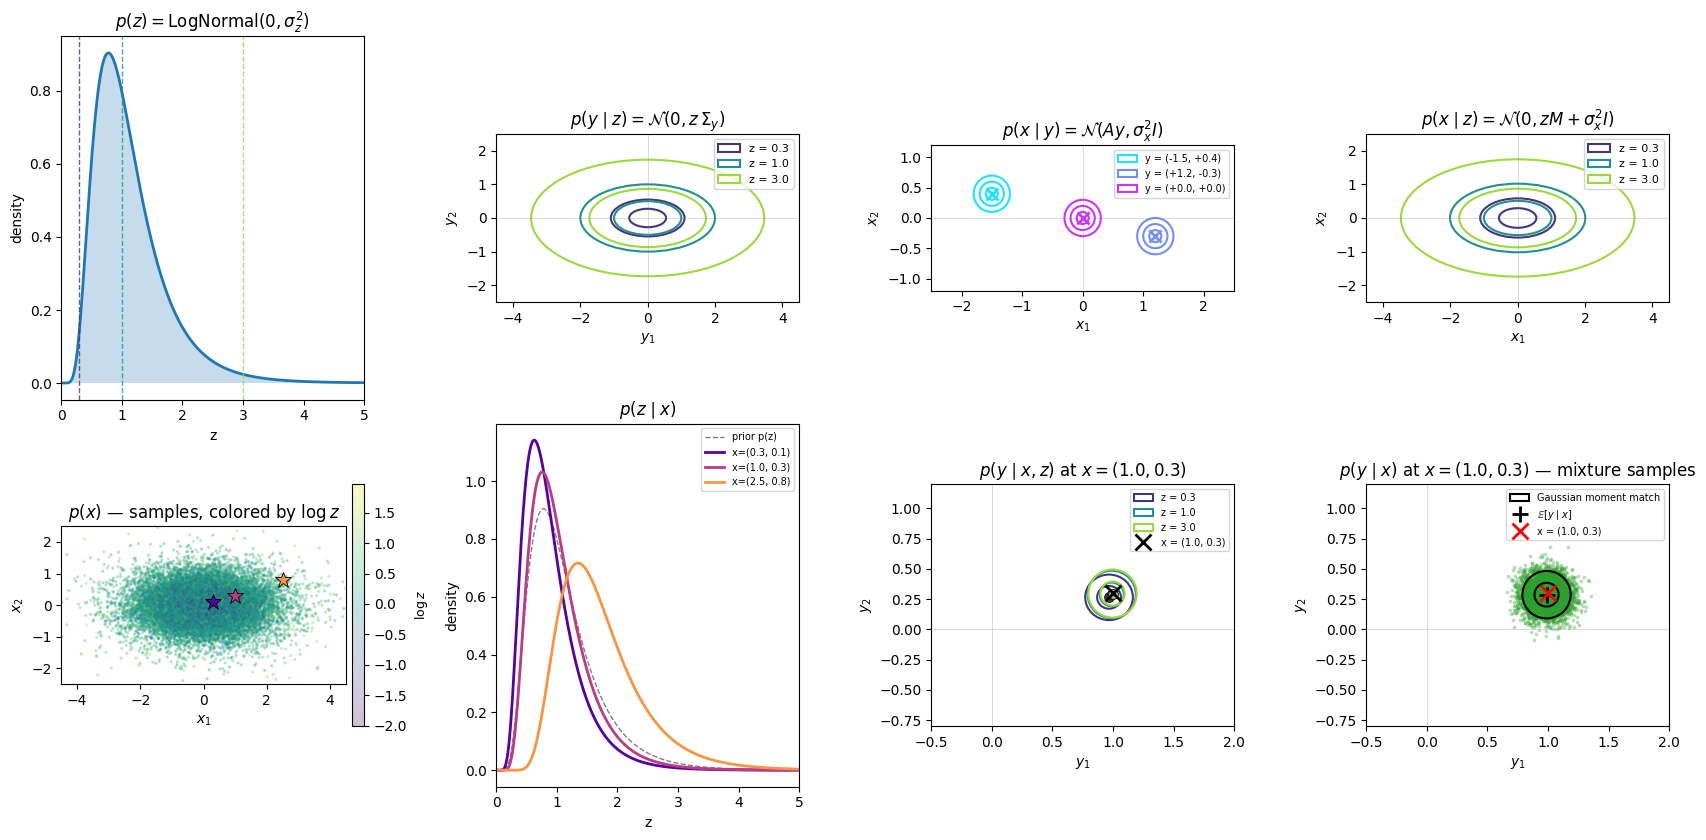

In [4]:
from a_datasets.gsm.data_flat import plot_distributions

plot_distributions(sigma_x=0.1)